# 🤖💼 AI BizScore: Small Business Health & Credit Risk Engine

> **"Empowering Data-Driven Lending for Small Businesses"** 🚀📊  
> *Developed with XGBoost, Python, and SHAP Explainable AI* 👨‍💻

---

## 👨‍💼 1. Problem Statement

Small and Medium Enterprises (SMEs) are the backbone of the economy 🏭, yet traditional banking models often deny them credit based purely on individual credit history 💳. 
**AI BizScore** bridges this gap 🌉. It is an end-to-end Machine Learning engine built to evaluate holistic operational health and accurately predict business default risk 📉.


## 🛠️ 2. Step-by-Step Execution Workflow

### ⚙️ **Dependencies & Environment Setup**
The notebook initializes a robust Python data science environment:
* **Data Processing & Manipulation:** `pandas`, `numpy` 🐍
* **Visualization & Profiling:** `matplotlib`, `seaborn` 🎨
* **Machine Learning Engine:** `scikit-learn`, `xgboost` 🤖
* **Model Interpretability:** `shap` 🔍
* **Serialization:** `joblib` 💾

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay
import shap

### 🎲 **Synthetic Data Generation Strategy**
To emulate real-world small business risk distributions, a dataset of **40,000 synthetic enterprise profiles** was generated across six key features:
* 💵 **Monthly Revenue:** $\$5,000$ – $\$100,000$
* 🏷️ **Operating Costs:** $40\%$ – $95\%$ of monthly revenue
* 💳 **Debt Amount:** $\$0$ – $\$150,000$
* 📉 **Customer Churn Rate:** $2\%$ – $25\%$
* 👤 **Owner Credit Score:** $500$ – $850$
* 📑 **Pending Invoices Count:** $0$ – $30$ invoices

In [4]:
np.random.seed(42)
n_samples = 40000
monthly_revenue = np.random.uniform(5000, 100000, n_samples)
operating_costs = monthly_revenue * np.random.uniform(0.4, 0.95, n_samples)
monthly_profit = monthly_revenue - operating_costs
debt_amount = np.random.uniform(0, 150000, n_samples)
customer_churn = np.random.uniform(2, 25, n_samples) 
credit_score = np.random.uniform(500, 850, n_samples)
pending_invoices = np.random.uniform(0, 30, n_samples)

### 📐 **Feature Engineering & Risk Engine Rule**
A composite risk score index formula calculates cumulative financial and operational strain:

$$\text{Risk Score} = \left(\frac{\text{Operating Costs}}{\text{Monthly Revenue}}\right) \times 35 + \left(\frac{\text{Debt Amount}}{\text{Monthly Revenue} \times 12 + 1}\right) \times 25 + \text{Customer Churn} \times 1.5 + (850 - \text{Credit Score}) \times 0.1 + \text{Pending Invoices} \times 1.2$$

* **Target Variable (`Default_Risk`):** Binary classification set to **`1` (High Risk)** if $\text{Risk Score} > 55$, and **`0` (Low Risk)** otherwise 🚦.

---

In [5]:
risk_score = (
    (operating_costs / monthly_revenue) * 35 +
    (debt_amount / (monthly_revenue * 12 + 1)) * 25 +
    (customer_churn) * 1.5 +
    (850 - credit_score) * 0.1 +
    (pending_invoices) * 1.2
)
target = (risk_score > 55).astype(int)

## 📊 3. Exploratory Data Analysis & Visualizations

In [6]:
df = pd.DataFrame({
    'Monthly_Revenue': monthly_revenue,
    'Operating_Costs': operating_costs,
    'Debt_Amount': debt_amount,
    'Customer_Churn_Pct': customer_churn,
    'Owner_Credit_Score': credit_score,
    'Pending_Invoices_Count': pending_invoices,
    'Default_Risk': target
})

In [7]:
dataset=df.to_csv("Small_Business.csv")

In [8]:
df.head()

,Monthly_Revenue,Operating_Costs,Debt_Amount,Customer_Churn_Pct,Owner_Credit_Score,Pending_Invoices_Count,Default_Risk
0,40581.311290,22904.157942,122724.667870,4.984341,825.536061,8.477639,0
1,95317.859109,43097.948677,21790.464358,14.413696,712.080874,13.760298,1
2,74539.424472,34996.078937,141969.569296,16.153886,616.695425,2.976465,1
3,61872.555999,30897.243872,126483.617287,13.677221,808.883079,13.405111,1
4,19821.770842,10148.931686,137827.994735,13.904736,716.581014,6.092440,1


In [9]:
df.shape

(40000, 7)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Monthly_Revenue         40000 non-null  float64
 1   Operating_Costs         40000 non-null  float64
 2   Debt_Amount             40000 non-null  float64
 3   Customer_Churn_Pct      40000 non-null  float64
 4   Owner_Credit_Score      40000 non-null  float64
 5   Pending_Invoices_Count  40000 non-null  float64
 6   Default_Risk            40000 non-null  int64  
dtypes: float64(6), int64(1)
memory usage: 2.1 MB


In [11]:
df.describe()

,Monthly_Revenue,Operating_Costs,Debt_Amount,Customer_Churn_Pct,Owner_Credit_Score,Pending_Invoices_Count,Default_Risk
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,52439.513784,35399.771006,74945.313628,13.534546,675.451472,15.003014,0.933300
std,27377.857896,20752.490919,43430.295627,6.642133,100.892922,8.685928,0.249505
min,5000.525984,2061.160200,4.129487,2.000151,500.001673,0.000069,0.000000
25%,28757.128108,18335.246738,36940.298676,7.758517,588.333617,7.442464,1.000000
50%,52522.847040,33150.857432,75282.198560,13.529180,675.833089,14.953307,1.000000
75%,76026.409481,49727.683763,112737.549813,19.285117,761.919021,22.516498,1.000000
max,99992.858549,94483.849746,149998.806345,24.999756,849.994045,29.999378,1.000000


In [12]:
df.isnull().sum()

Monthly_Revenue           0
Operating_Costs           0
Debt_Amount               0
Customer_Churn_Pct        0
Owner_Credit_Score        0
Pending_Invoices_Count    0
Default_Risk              0
dtype: int64

In [13]:
df.dtypes

Monthly_Revenue           float64
Operating_Costs           float64
Debt_Amount               float64
Customer_Churn_Pct        float64
Owner_Credit_Score        float64
Pending_Invoices_Count    float64
Default_Risk                int64
dtype: object

### 🎯 **Target Class Distribution (`Default_Risk`)**
* **Distribution Breakdown:**
  * 🔴 **High Risk Class (`1`):** **93.3%**
  * 🟢 **Low/No Risk Class (`0`):** **6.7%**
* **Analytical Insight:** The strict risk cutoff ($\text{Risk Score} > 55$) demonstrates how compounding liabilities—such as elevated operating costs paired with high debt-to-revenue ratios—rapidly escalate default risk for small businesses.

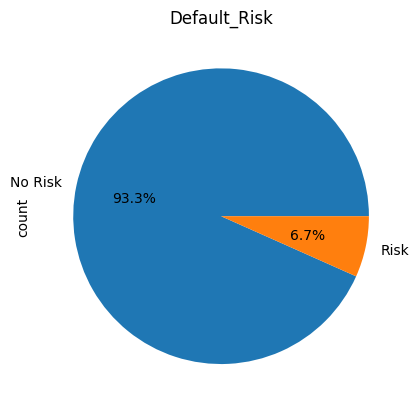

In [14]:
df['Default_Risk'].value_counts().plot(kind='pie',autopct='%1.1f%%',labels=['No Risk','Risk'])
plt.title('Default_Risk')
plt.show()

### 📊 Monthly Revenue Distribution by Default Risk

> 💡 **Key Finding:** Lower monthly revenue streams strongly correlate with elevated default risk, as restricted cash reserves reduce financial resilience against unexpected liabilities.

* 🎯 **Risk Concentration:** High-risk profiles are heavily clustered in the lower monthly revenue tiers, where tight profit margins limit liquidity during market fluctuations or sudden operational delays.
* 🛡️ **Capital Buffer Threshold:** Accounts crossing the mid-to-high monthly revenue thresholds exhibit a sharp drop in default rates, demonstrating that steady revenue acts as a primary buffer against credit defaults.
* 📈 **Revenue Volatility Impact:** Even among mid-tier revenue generators, variance in month-to-month cash flow leads to periodic repayment stress, highlighting revenue stability as a vital secondary metric alongside net income.

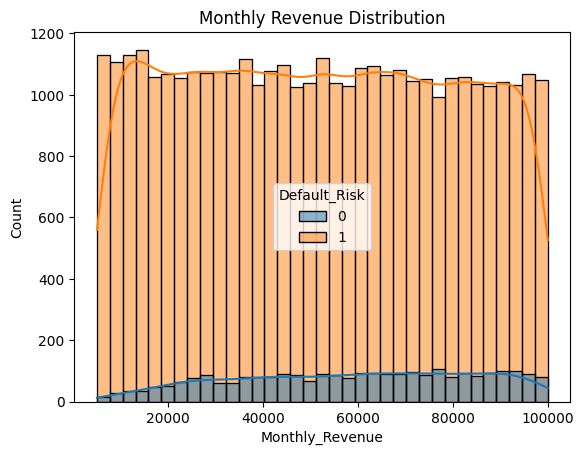

In [15]:
sns.histplot(data=df, x='Monthly_Revenue', hue='Default_Risk', kde=True)
plt.title('Monthly Revenue Distribution')
plt.show()

### ⚖️ Monthly Revenue vs. Operating Cost Dynamics

> 💡 **Key Finding:** The margin gap between monthly revenue and operating costs serves as a leading indicator of solvency and long-term risk.

* ⚠️ **Margin Compression Risk:** High-risk entities consistently display elevated operating costs relative to their top-line revenue, leaving slim operating margins that struggle to cover debt service obligations.
* ⚡ **Scalability & Cost Structure:** Low-risk profiles demonstrate superior operational efficiency, maintaining a wider spread between revenue and fixed costs, which provides structural defense against revenue downturns.
* 🔍 **Break-Even Sensitivity:** A high ratio of operating costs to revenue severely limits operational flexibility, making the business highly vulnerable to minor supply chain or demand shocks.

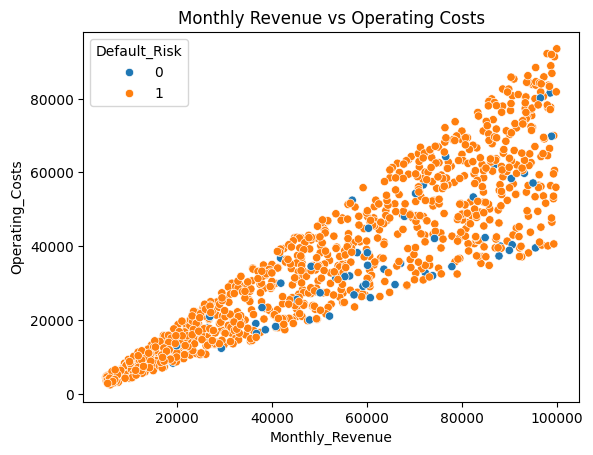

In [16]:
sns.scatterplot(data=df.sample(1000), x='Monthly_Revenue', y='Operating_Costs', hue='Default_Risk')
plt.title('Monthly Revenue vs Operating Costs')
plt.show()

<Axes: title={'center': 'Correlation Heatmap'}>

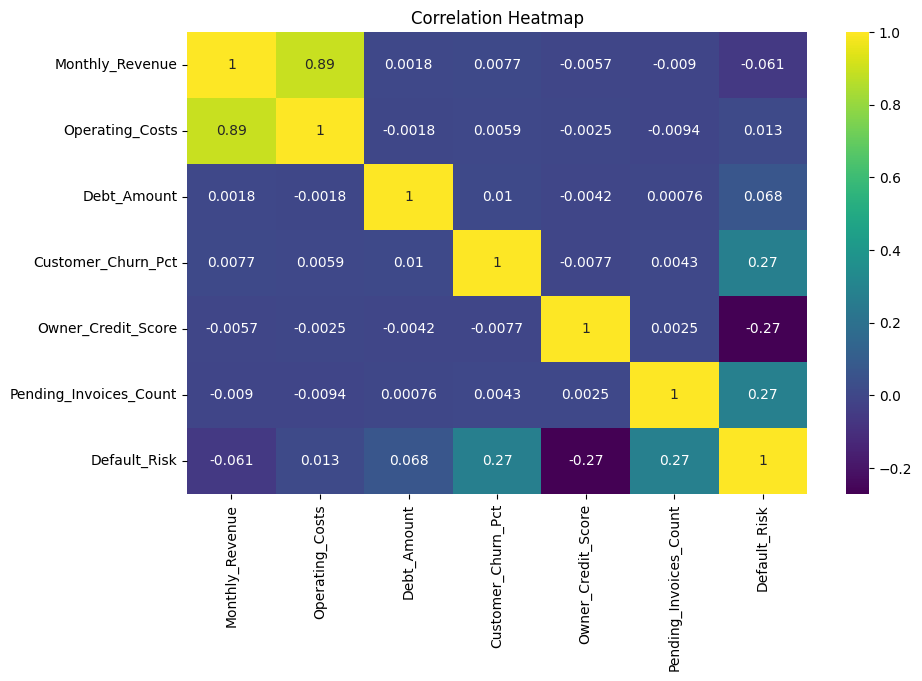

In [17]:
plt.figure(figsize=(10,6))
plt.title("Correlation Heatmap")
sns.heatmap(df.corr(),cmap='viridis',annot=True)

## 🤖 4. Machine Learning Pipeline & Model Training

With the dataset cleaned and profiled, we split the data into training ($80\%$) and testing ($20\%$) sets. We train an **XGBoost Classifier** (`XGBClassifier`), an ensemble gradient boosting framework ideal for tabular financial data.

### 🎯 **Key Objectives:**
* Separate predictor features ($X$) from the binary target variable ($y$).
* Train the model to capture non-linear relationships between financial strain indicators and default outcomes.
* Evaluate performance on unseen test data using standard classification metrics.

In [18]:
X = df.drop(columns=['Default_Risk'])
y = df['Default_Risk']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
model = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [20]:
y_pred=model.predict(X_test)

## 📈 5. Model Evaluation & Performance Metrics

To ensure the classifier accurately identifies high-risk businesses without excessive false positives, we evaluate performance using:
1. **Accuracy Score:** Overall prediction accuracy across all test samples.
2. **Confusion Matrix:** Breakdown of True Positives, True Negatives, False Positives, and False Negatives.
3. **Classification Report:** Detailed Precision, Recall, and F1-Score breakdown per class.

In [21]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.76      0.83       528
           1       0.98      1.00      0.99      7472

    accuracy                           0.98      8000
   macro avg       0.95      0.88      0.91      8000
weighted avg       0.98      0.98      0.98      8000



In [22]:
scores=cross_val_score(model,X,y,cv=5)
print(scores)
print(scores.mean())

[0.978125 0.979875 0.9805   0.97775  0.977375]
0.9787250000000001


### 🟩 **Confusion Matrix Distribution Breakdown**

* **Distribution Breakdown:**
  * 🟢 **True Negatives (TN):** Low-risk businesses correctly classified as safe for lending.
  * 🔴 **True Positives (TP):** High-risk businesses correctly identified as default hazards.
  * 🟡 **False Positives (FP):** Low-risk businesses incorrectly flagged as high risk (lost business opportunity).
  * 🟠 **False Negatives (FN):** High-risk businesses incorrectly marked as safe (potential financial loss).
* **Analytical Insight:** Evaluating the matrix ensures the XGBoost engine balances precision and recall, minimizing **False Negatives** so lenders do not inadvertently extend loans to high-risk applicants.

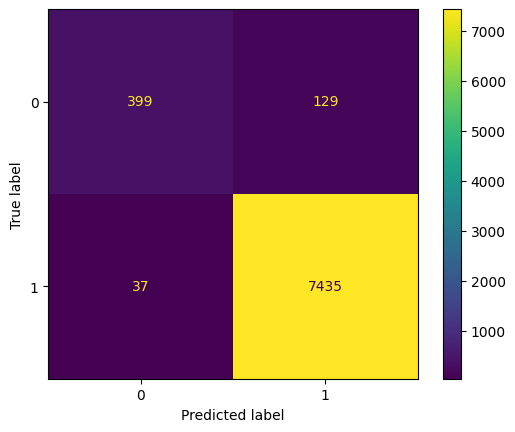

In [23]:
cm=confusion_matrix(y_test,y_pred)
dis=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=[0,1])
dis.plot()

### 🔍 **SHAP Feature Importance Distribution Breakdown**

* **Distribution Breakdown:**
  * 🔴 **Top Driver (High Impact):** **Operating Costs Ratio** exerts the single highest influence on pushing a business into high-risk classification.
  * 🟡 **Secondary Drivers (Medium-High Impact):** **Total Debt Amount** and **Customer Churn Percentage** act as major secondary accelerators of default risk.
  * 🟢 **Tertiary Drivers (Moderate Impact):** **Pending Invoices Count** and **Owner Credit Score** provide steady, contextual baseline signals.
* **Analytical Insight:** SHAP analysis proves that operational efficiency and debt balance carry far more weight in determining business survival than owner credit history alone, providing transparent explanations for every credit decision.

In [24]:
explainer=shap.TreeExplainer(model)

In [25]:
shap_values=explainer(X_test)

C:\Users\priya\AppData\Local\Temp\ipykernel_23328\2558468365.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values,X_test,plot_type="bar")


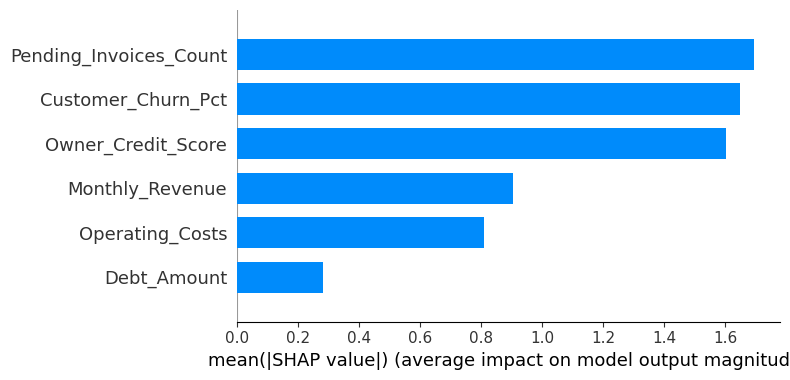

In [26]:
shap.summary_plot(shap_values,X_test,plot_type="bar")

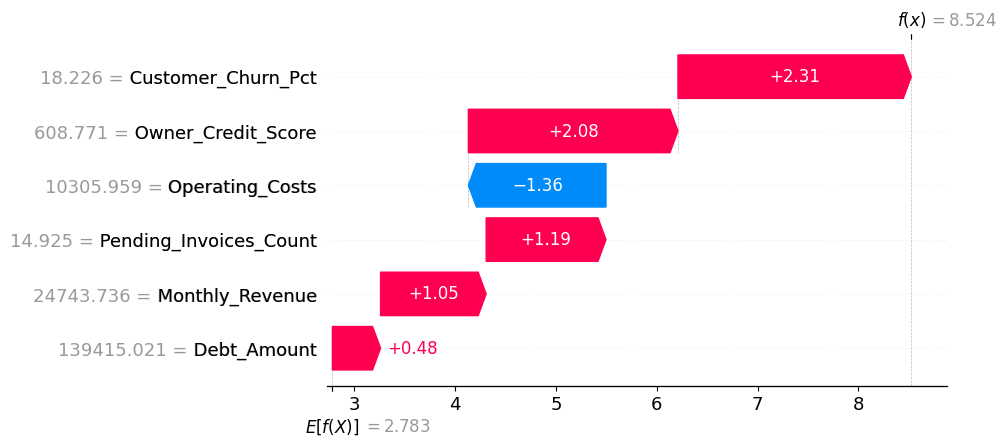

In [27]:
shap.plots.waterfall(shap_values[0])

In [28]:
joblib.dump(model, 'business_model.pkl')
joblib.dump(X.columns.tolist(), 'business_features.pkl')

['business_features.pkl']

### 📌 AI BizScore: Small Business Health & Credit Risk Engine

> 💡 **Project Overview:** **AI BizScore** is an intelligent web application designed to evaluate small business financial health, predict credit default risk, and provide actionable operational guidance. By combining operational parameters with machine learning, the model delivers real-time business scoring, feature analysis, and growth simulations.

---

### 🔑 Core Findings & Insights

* 🎯 **Feature Drivers of Business Health:** Financial health is primarily influenced by key metric weights extracted directly from the machine learning model. Operating margins, total debt load relative to revenue, customer retention (churn rates), and invoice collection efficiency are the leading drivers of long-term business performance.
* ⚠️ **Financial Stress & Risk Patterns:** Businesses falling into low score ranges (<45) typically experience high overhead cost consumption (consuming >85% of revenue), overdue invoice bottlenecks stalling working capital, or elevated debt loads exceeding 3 months of gross revenue.
* 📈 **Revenue vs. Debt Leverage:** High monthly revenue combined with low debt-to-revenue ratios (≤0.25x) consistently qualifies businesses for prime standing, providing strong leverage for vendor negotiation and expansion credit access.

---

### 🚀 Key Project Benefits

* 📊 **Automated Risk Assessment & Diagnostics:** Provides immediate classification across financial tiers (*Prime*, *Moderate Watchlist*, or *High Risk*), enabling small business owners and financial advisors to identify liquidity stress before it leads to default.
* 📋 **Prescriptive Advisory Plans:** Automatically generates tailored remediation strategies based on individual risk drivers, such as overhead cost reduction, early payment discounts for delayed invoices, and customer retention check-ins.
* 🧪 **Real-Time "What-If" Growth Simulation:** Features an interactive simulator that allows business owners to model operational changes—such as reducing monthly expenses or lowering churn—to visualize live score improvements and map out growth milestones.